## Import Libraries
We import the necessary Python modules and PyTorch components that will be used throughout our project.  

**random** :   
    - Useful for controlling random behavior, though not heavily used here.  

**NumPy** :   
    - Complementary numerical library for array operations.  

**PyTorch (torch)** :   
    - Core library for handling tensors, automatic differentiation, and GPU computation. 


**nn and optim** :   
    - Provide pre-built neural network layers (e.g., Conv2d, Linear) and optimization methods (e.g., Adam).  


**torchvision.datasets** :   
    - Simplifies loading common datasets (such as FashionMNIST).  


**torchvision.transforms** :   
    - Preprocessing utilities (e.g., ToTensor()).  


**DataLoader** :   
    - Groups samples into batches for efficient training.  


**torchmetrics** :   
    - Offers ready-to-use metrics (Accuracy, Precision, Recall) that integrate well with PyTorch.  

In [476]:
# -------------------------
# Standard Library Imports
# -------------------------
import random                   # Python's built-in random module
import pandas as pd             # Panda for creating dataframe
import matplotlib.pyplot as plt # Visualizing the image
import seaborn as sns           # Visualizing the chart 

# -------------------------
# Third-Party Library Imports
# -------------------------
import numpy as np            # NumPy for numerical computations
import torch                  # PyTorch for tensor operations
import torch.nn as nn         # Neural network layers and functions
import torch.optim as optim   # Optimization algorithms

# -------------------------
# TorchVision and Transforms
# -------------------------
from torchvision import datasets              # Popular datasets (e.g., ImageFolder)
from torchvision.transforms import transforms # Image transformations (e.g., Resize, Normalize)

# -------------------------
# PyTorch Data Utilities
# -------------------------
from torch.utils.data import Dataset, DataLoader  # Custom dataset creation and batch loading

# -------------------------
# TorchMetrics for Evaluation
# -------------------------
from torchmetrics import Accuracy, Precision, Recall  # Standard evaluation metrics for classification

In [477]:
# -------------------------
# Set the Seed for Reproducibility
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [478]:
# -------------------------
# Define Transformers for Training and Test Datasets
# -------------------------
# Define transforms with augmentation
train_transforms_1 = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.3,
        scale=(0.02, 0.2),
        ratio=(0.3, 3.3)
    )
])

train_transforms_2 = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10
    ),
    transforms.ToTensor()
])

train_transforms_3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

train_transforms_4 = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.3,
        scale=(0.02, 0.2),
        ratio=(0.3, 3.3)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])


## Load the Dataset
In this step, we download and load the **`FashionMNIST`** dataset, split into a training set (train=True) and a test set (train=False). We specify a root directory (./data) where the data will be stored, and use **`download=True`** to automatically fetch the dataset if it does not exist locally. By applying **`transforms.ToTensor()`**, each image is converted from a PIL image to a normalized PyTorch tensor, simplifying the process of feeding image data into our model.

In [479]:
# -------------------------
# Load the Training and Test Datasets
# -------------------------
# FashionMNIST is automatically downloaded to './data' (if not already present).
# The transform 'ToTensor()' converts PIL images to PyTorch Tensors.
train_data = datasets.FashionMNIST(
    root= './data', 
    train= True, 
    download= True, 
    # transform= transforms.ToTensor()
    transform= train_transforms_4
)
test_data = datasets.FashionMNIST(
    root= './data', 
    train= False, 
    download= True, 
    # transform= transforms.ToTensor()
    transform= test_transform
)

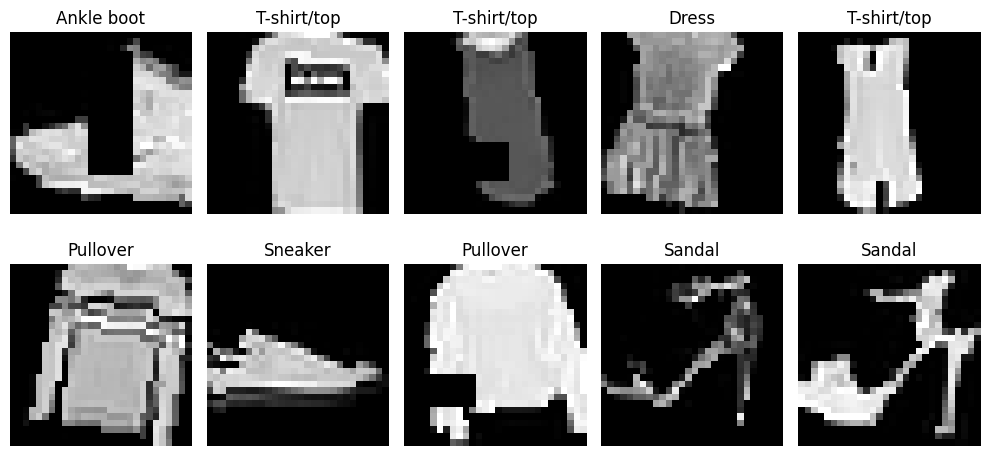

In [480]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # Create a 2x5 grid

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]  # Get image and label
    image = image.squeeze().numpy()  # Convert tensor to NumPy

    ax.imshow(image, cmap="gray")
    ax.set_title(f"{train_data.classes[label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Inspect the Dataset
Here, we gather crucial information about our datasets before training. We confirm the number of images available in each split and quickly inspect the shapes of the first training and test samples to ensure they match the expected **`one-channel`**, **`28×28`** **`format`**. We calculate the **`total number of pixels (28 * 28 = 784)`** to understand the raw input dimension for fully connected layers, and we also print out the class labels recognized by **`FashionMNIST`**, ultimately confirming there are **`10 unique categories`** to classify.

In [481]:
# -------------------------
# Basic Dataset Information
# -------------------------
# Print the number of samples in each dataset
print(f"Number of samples in train_data: {len(train_data)}")
print(f"Number of samples in test_data: {len(test_data)}", "\n")

# Inspect the first sample from each dataset
image, label = train_data[0]
image2, label2 = test_data[0]

# Print the shapes of the images
print(f"Train image shape: {image.shape}")
print(f"Test image shape: {image2.shape}", "\n")

# Calculate and print the number of features per image
# For FashionMNIST, each image is 1 channel with size 28 x 28.
num_features = image.shape[1] * image.shape[2]
print(f"Number of features per image: {num_features}", "\n")

# Check and print the available class labels
print(f"Unique class labels in train: {train_data.classes}")
print(f"Unique class labels in test: {test_data.classes}", "\n")
classes = train_data.classes

num_classes = len(train_data.classes)
print(f"Number of unique class labels in train: {num_classes}")

Number of samples in train_data: 60000
Number of samples in test_data: 10000 

Train image shape: torch.Size([1, 28, 28])
Test image shape: torch.Size([1, 28, 28]) 

Number of features per image: 784 

Unique class labels in train: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Unique class labels in test: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 

Number of unique class labels in train: 10


## Defining the Convolutional Neural Network (CNN) 

This step constructs a **`convolutional neural network (CNN)`** for image classification. It consists of **`two convolutional blocks`** (each followed by ReLU activation and max pooling) that progressively extract spatial features from the input. Using **`Flatten`** transforms the 2D feature maps into a 1D vector, suitable for the final linear (fully connected) layer. We dynamically determine the output size of the feature extraction part by passing a dummy tensor, ensuring that our linear layer’s input dimension matches the extracted feature dimension.


In [482]:
# -------------------------
# Define the CNN Class
# -------------------------
class CNN_net(nn.Module):
    def __init__(self, num_classes):
        super(CNN_net, self).__init__()

        # Feature extraction layers: 
        # 1) Convolution layer with 16 output channels, kernel 3x3, stride=1, padding=1
        # 2) ReLU activation function
        # 3) 2x2 Max Pooling with stride=2
        # 4) Another Conv layer (16 -> 32 channels), ReLU, and 2x2 MaxPool
        # 5) Flatten the 2D feature maps to a 1D vector
        self.feature_extraction = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Flatten()                                                        # Flatten feature maps into a single vector
        )

        # Dynamically compute the number of features after the feature extraction layers.
        with torch.no_grad():
            image_size = train_data[0][0].shape[1]                              # For FashionMNIST, this should be 28.
            sample_input = torch.zeros(1, 1, image_size, image_size)            # A dummy input
            feature_map = self.feature_extraction(sample_input)                 # Extract Number of features
            num_features = feature_map.shape[1]                                 # Flattened feature size
            # print("Feature map shape:", feature_map.shape)                    # Debugging output

        # A single fully connected layer to map extracted features to class scores.
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        Forward pass:
        1) Extract features through the convolution, activation, and pooling layers.
        2) Flatten the features into a 1D vector.
        3) Pass the flattened vector to the fully connected layer for classification.
        """
        x = self.feature_extraction(x)                                          # Convolution & Pooling
        x = self.classifier(x)                                                  # Linear layer
        return x


## Prepare the Training DataLoader

We now wrap our training dataset in a **`DataLoader`**, which handles batching and data shuffling. Each iteration will yield a batch of **`10`** samples (images and labels), and **`shuffle=True`** ensures that data is randomized each epoch, improving the robustness of training by reducing any unintended ordering effects in the dataset.

In [483]:
# -------------------------
# Define the Training DataLoader
# -------------------------
# Create batches of size 10 from the training dataset, and shuffle the data.
dataloader_train = DataLoader(
    train_data,
    batch_size=10,
    shuffle=True,
)

## Define the Training Function
In this function, we iterate over the **`training data`** for a specified number of epochs, computing and **`backpropagating`** the **`cross-entropy loss`** after each forward pass. The criterion is **`nn.CrossEntropyLoss`**, well-suited to multi-class classification. Each batch updates the model’s parameters through the optimizer (**`optimizer.step()`**), and we track the average loss across all batches per epoch, providing a measure of training progress.

In [484]:
# -------------------------
# Define the Training Function
# -------------------------
def train_model(optimizer, net, num_epochs):
    """
    Trains a given neural network for a specified number of epochs.
    
    Parameters:
    -----------
    optimizer: Torch Optimizer
        The optimizer responsible for updating model parameters.
    net: nn.Module
        The neural network model to be trained.
    num_epochs: int
        Number of training epochs.
    
    Returns:
    --------
    None
    """
    # Initialize the loss function
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        running_loss = 0.0  # Accumulate loss over each epoch
        num_processed = 0   # Track how many samples have been processed

        for features, labels in dataloader_train:
            # Zero out the gradients from the previous iteration
            optimizer.zero_grad()
            # Forward pass
            output = net(features)
            # Calculate loss
            loss = criterion(output, labels)
            # Backward pass
            loss.backward()
            # Update weights
            optimizer.step()
            # Accumulate the loss
            running_loss += loss.item()
            # Count the number of processed samples
            num_processed += len(labels)

        # Print the average training loss for this epoch
        train_loss = running_loss / len(dataloader_train)
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}")

## Instantiate and Train the Model

Here, we create our **`CNN instance`** and an **`Adam optimizer`**, which is known for its adaptive learning rate and efficient convergence properties. We set the **`learning rate to 0.01`** and call our training function for indicated epochs (more epochs are typically needed for better accuracy). During training, the optimizer updates the CNN’s weights, reducing the cross-entropy loss and hopefully improving model performance.



In [485]:
# -------------------------
# Instantiate the Model and Optimizer
# -------------------------
net = CNN_net(num_classes)             # Create an instance of the CNN
optimizer = optim.Adam(net.parameters(), lr=0.001)  # Use Adam optimizer with a learning rate of 0.01

# -------------------------
# Train the Model
# -------------------------
train_model(
    optimizer=optimizer,
    net=net,
    num_epochs=10
)

Epoch 1/10, Training Loss: 0.7467
Epoch 2/10, Training Loss: 0.5734
Epoch 3/10, Training Loss: 0.5211
Epoch 4/10, Training Loss: 0.4987
Epoch 5/10, Training Loss: 0.4786
Epoch 6/10, Training Loss: 0.4602
Epoch 7/10, Training Loss: 0.4572
Epoch 8/10, Training Loss: 0.4458
Epoch 9/10, Training Loss: 0.4393
Epoch 10/10, Training Loss: 0.4336


## Define Evaluation Metrics

Next, we set up three metrics—**`accuracy`**, **`precision`**, and **`recall`**—to assess different aspects of our model’s predictions. Specifying **`task='multiclass'`** and the number of classes ensures the metrics handle multi-class classification correctly. We use **`average=None`** for both precision and recall to capture per-class performance, allowing us to see if the model struggles with any particular category of clothing.

In [486]:
# -------------------------
# Define the Evaluation Metrics
# -------------------------
# Using TorchMetrics to calculate Accuracy, Precision, and Recall.
accuracy_metric = Accuracy(task='multiclass', num_classes=num_classes)
precision_metric = Precision(task='multiclass', num_classes=num_classes, average=None)
recall_metric = Recall(task='multiclass', num_classes=num_classes, average=None)

## Evaluate on the Test Set
We switch the model to evaluation mode using net.eval(), which disables training behaviors like dropout. We also create a test **`DataLoader`** and run inference in a **`torch.no_grad()`** context to avoid computing gradients. For each batch, we **`reshape`** the images if needed and make predictions by choosing the class with the highest logit (**`argmax`**). The predictions and labels are then passed to our previously defined TorchMetrics objects to accumulate performance statistics across the entire test dataset.

In [487]:
# -------------------------
# Evaluate on Test Set
# -------------------------
net.eval()  # Set the network to evaluation mode (disable dropout, batch norm, etc.)
predictions = []

# Create a DataLoader for the test dataset (not defined above, so define it here)
dataloader_test = DataLoader(
    test_data,
    batch_size=10,
    shuffle=False,
)

# Disable gradient tracking for evaluation
with torch.no_grad():
    image_size = train_data[0][0].shape[1]  # This should be 28 for FashionMNIST
    for i, (features, labels) in enumerate(dataloader_test):
        # Forward pass; ensure features are in the correct shape (N, C, H, W)
        output = net.forward(features.reshape(-1, 1, image_size, image_size))
        # Get the predicted class by picking the highest logit
        cat = torch.argmax(output, dim=-1)
        # Store predictions
        predictions.extend(cat.tolist())
        # Update evaluation metrics
        accuracy_metric(cat, labels)
        precision_metric(cat, labels)
        recall_metric(cat, labels)


## Compute and Print Final Metrics

Finally, we call the **`.compute()`** method on each metric to convert the accumulated statistics into concrete values. We print the overall **`accuracy`**, followed by **`per-class precision`** and **`recall`**, allowing us to see which classes the model predicts well and where it might be making mistakes. This completes our pipeline for training and evaluating the **`CNN`** on **`FashionMNIST`**.

In [488]:
# -------------------------
# Compute the Final Metrics
# -------------------------
accuracy = accuracy_metric.compute().item()
precision = precision_metric.compute().tolist()
recall = recall_metric.compute().tolist()

# -------------------------
# Print Evaluation Results
# -------------------------
print('Accuracy:', accuracy, "\n")
print('Precision (per class):')
for class_name, prec in zip(classes, precision):
    print(f'{class_name} : {prec:.4f}')

print("\n", 'Recall (per class):')
for class_name, rec in zip(classes, recall):
    print(f'{class_name} : {rec:.4f}')

Accuracy: 0.8740000128746033 

Precision (per class):
T-shirt/top : 0.7517
Trouser : 0.9959
Pullover : 0.7688
Dress : 0.8619
Coat : 0.7907
Sandal : 0.9926
Shirt : 0.7478
Sneaker : 0.8801
Bag : 0.9808
Ankle boot : 0.9817

 Recall (per class):
T-shirt/top : 0.9110
Trouser : 0.9680
Pullover : 0.8610
Dress : 0.9110
Coat : 0.7630
Sandal : 0.9440
Shirt : 0.5040
Sneaker : 0.9910
Bag : 0.9730
Ankle boot : 0.9140


In [489]:
# Create DataFrame
df_results = pd.DataFrame({"Precision": precision, "Recall": recall}, index=classes)

# Add accuracy as a separate row
df_results.loc["Overall Accuracy"] = [accuracy, None]  # Recall not applicable

# Save as CSV for easy comparison
df_results.to_csv("model_transform_4.csv")

In [490]:
df = pd.read_csv("model_before_transform.csv")

df

,Unnamed: 0,Precision,Recall
0,T-shirt/top,0.879917,0.850
1,Trouser,0.990844,0.974
2,Pullover,0.826446,0.900
3,Dress,0.928042,0.877
4,Coat,0.880503,0.840
5,Sandal,0.982811,0.972
6,Shirt,0.743925,0.796
7,Sneaker,0.955956,0.955
8,Bag,0.986735,0.967
9,Ankle boot,0.947317,0.971


In [491]:
file_list = ["model_before_transform.csv", "model_transform_1.csv", "model_transform_2.csv", "model_transform_3.csv", "model_transform_4.csv"]

transformer_list = ["Only ToTensor", "Transformer_1", "Transformer_2", "Transformer_3", "Transformer_4"]

zip_list = list(zip(file_list, transformer_list))

zip_list

[('model_before_transform.csv', 'Only ToTensor'),
 ('model_transform_1.csv', 'Transformer_1'),
 ('model_transform_2.csv', 'Transformer_2'),
 ('model_transform_3.csv', 'Transformer_3'),
 ('model_transform_4.csv', 'Transformer_4')]

In [492]:
df_accuracy = pd.DataFrame(columns=["Transformer Set", "Model's Accuracy"])

df_accuracy

,Transformer Set,Model's Accuracy


In [493]:
n = 0

for file, name in zip_list :
    df = pd.read_csv(file)

    precision_value = df.loc[10, "Precision"]

    df_accuracy.loc[n, "Transformer Set"] = name

    df_accuracy.loc[n, "Model's Accuracy"] = precision_value 

    n += 1

df_accuracy

,Transformer Set,Model's Accuracy
0,Only ToTensor,0.9102
1,Transformer_1,0.8743
2,Transformer_2,0.8811
3,Transformer_3,0.9104
4,Transformer_4,0.874


In [494]:
df_list = []
df_list_2 = []

for file, label in zip_list :
    df = pd.read_csv(file)

    recall_map = df.set_index("Unnamed: 0")["Recall"].to_dict()
    recall_map.pop("Overall Accuracy", None)

    recall_map["Transformer Set"] = label

    df_list.append(recall_map)

    precision_map = df.set_index("Unnamed: 0")["Precision"].to_dict()
    precision_map.pop("Overall Accuracy", None)

    precision_map["Transformer Set"] = label
    
    df_list_2.append(precision_map)

In [495]:
df_recall = pd.DataFrame(df_list)
cols = ["Transformer Set"] + [col for col in df_recall.columns if col != "Transformer Set"]
df_recall = df_recall[cols]

df_recall

,Transformer Set,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,Only ToTensor,0.850,0.974,0.900,0.877,0.840,0.972,0.796,0.955,0.967,0.971
1,Transformer_1,0.846,0.984,0.764,0.874,0.871,0.960,0.565,0.966,0.970,0.943
2,Transformer_2,0.793,0.977,0.710,0.906,0.871,0.967,0.695,0.983,0.977,0.932
3,Transformer_3,0.908,0.987,0.894,0.889,0.869,0.981,0.672,0.969,0.974,0.961
4,Transformer_4,0.911,0.968,0.861,0.911,0.763,0.944,0.504,0.991,0.973,0.914


In [496]:
df_precision = pd.DataFrame(df_list_2)
cols = ["Transformer Set"] + [col for col in df_precision.columns if col != "Transformer Set"]
df_precision = df_precision[cols]

df_precision

,Transformer Set,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,Only ToTensor,0.879917,0.990844,0.826446,0.928042,0.880503,0.982811,0.743925,0.955956,0.986735,0.947317
1,Transformer_1,0.800378,0.956268,0.839560,0.890928,0.721624,0.983607,0.693252,0.920877,0.972919,0.963228
2,Transformer_2,0.831237,0.983887,0.899873,0.856333,0.793984,0.988753,0.627823,0.910185,0.981910,0.982086
3,Transformer_3,0.826958,0.984048,0.809050,0.942736,0.842871,0.973214,0.829630,0.956565,0.972056,0.973658
4,Transformer_4,0.751650,0.995885,0.768750,0.861873,0.790674,0.992639,0.747774,0.880107,0.980847,0.981740


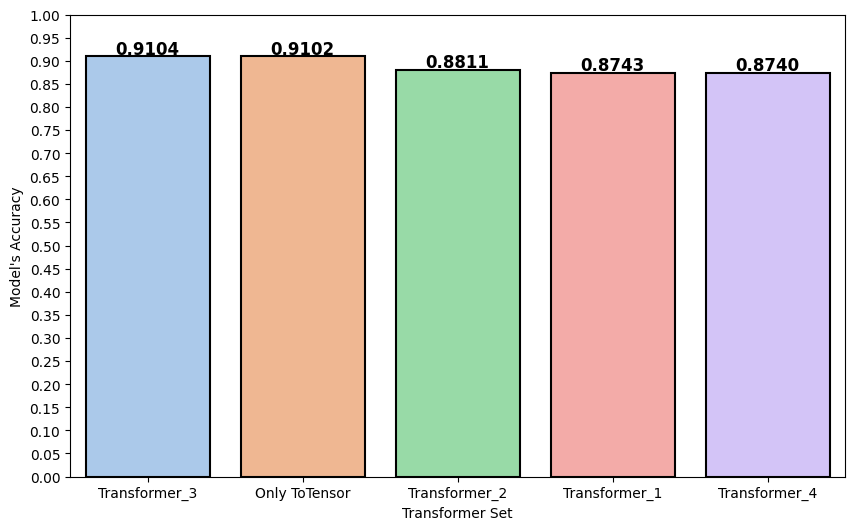

In [497]:
# Set figure size
plt.figure(figsize=(10, 6))

# Create bar plot with custom colors and edge outlines
sns.barplot(data = df_accuracy.sort_values(by= "Model's Accuracy", ascending= False), 
            x = "Transformer Set", 
            y = "Model's Accuracy", 
            hue = "Transformer Set",
            palette = "pastel", 
            edgecolor = "black", 
            linewidth = 1.5)

# Adjust y-axis ticks for better differentiation
plt.yticks(ticks=np.arange(0, 1.05, 0.05))  # Adjust scale based on your data range

# Add value labels on top of each bar
for index, row in enumerate(df_accuracy["Model's Accuracy"].sort_values(ascending= False)):
    plt.text(index, row + 0.005, f"{row:.4f}", ha='center', fontsize=12, fontweight='bold')

# Remove legend (since hue is redundant)
plt.legend([], [], frameon=False)

# Show the improved plot
plt.show()

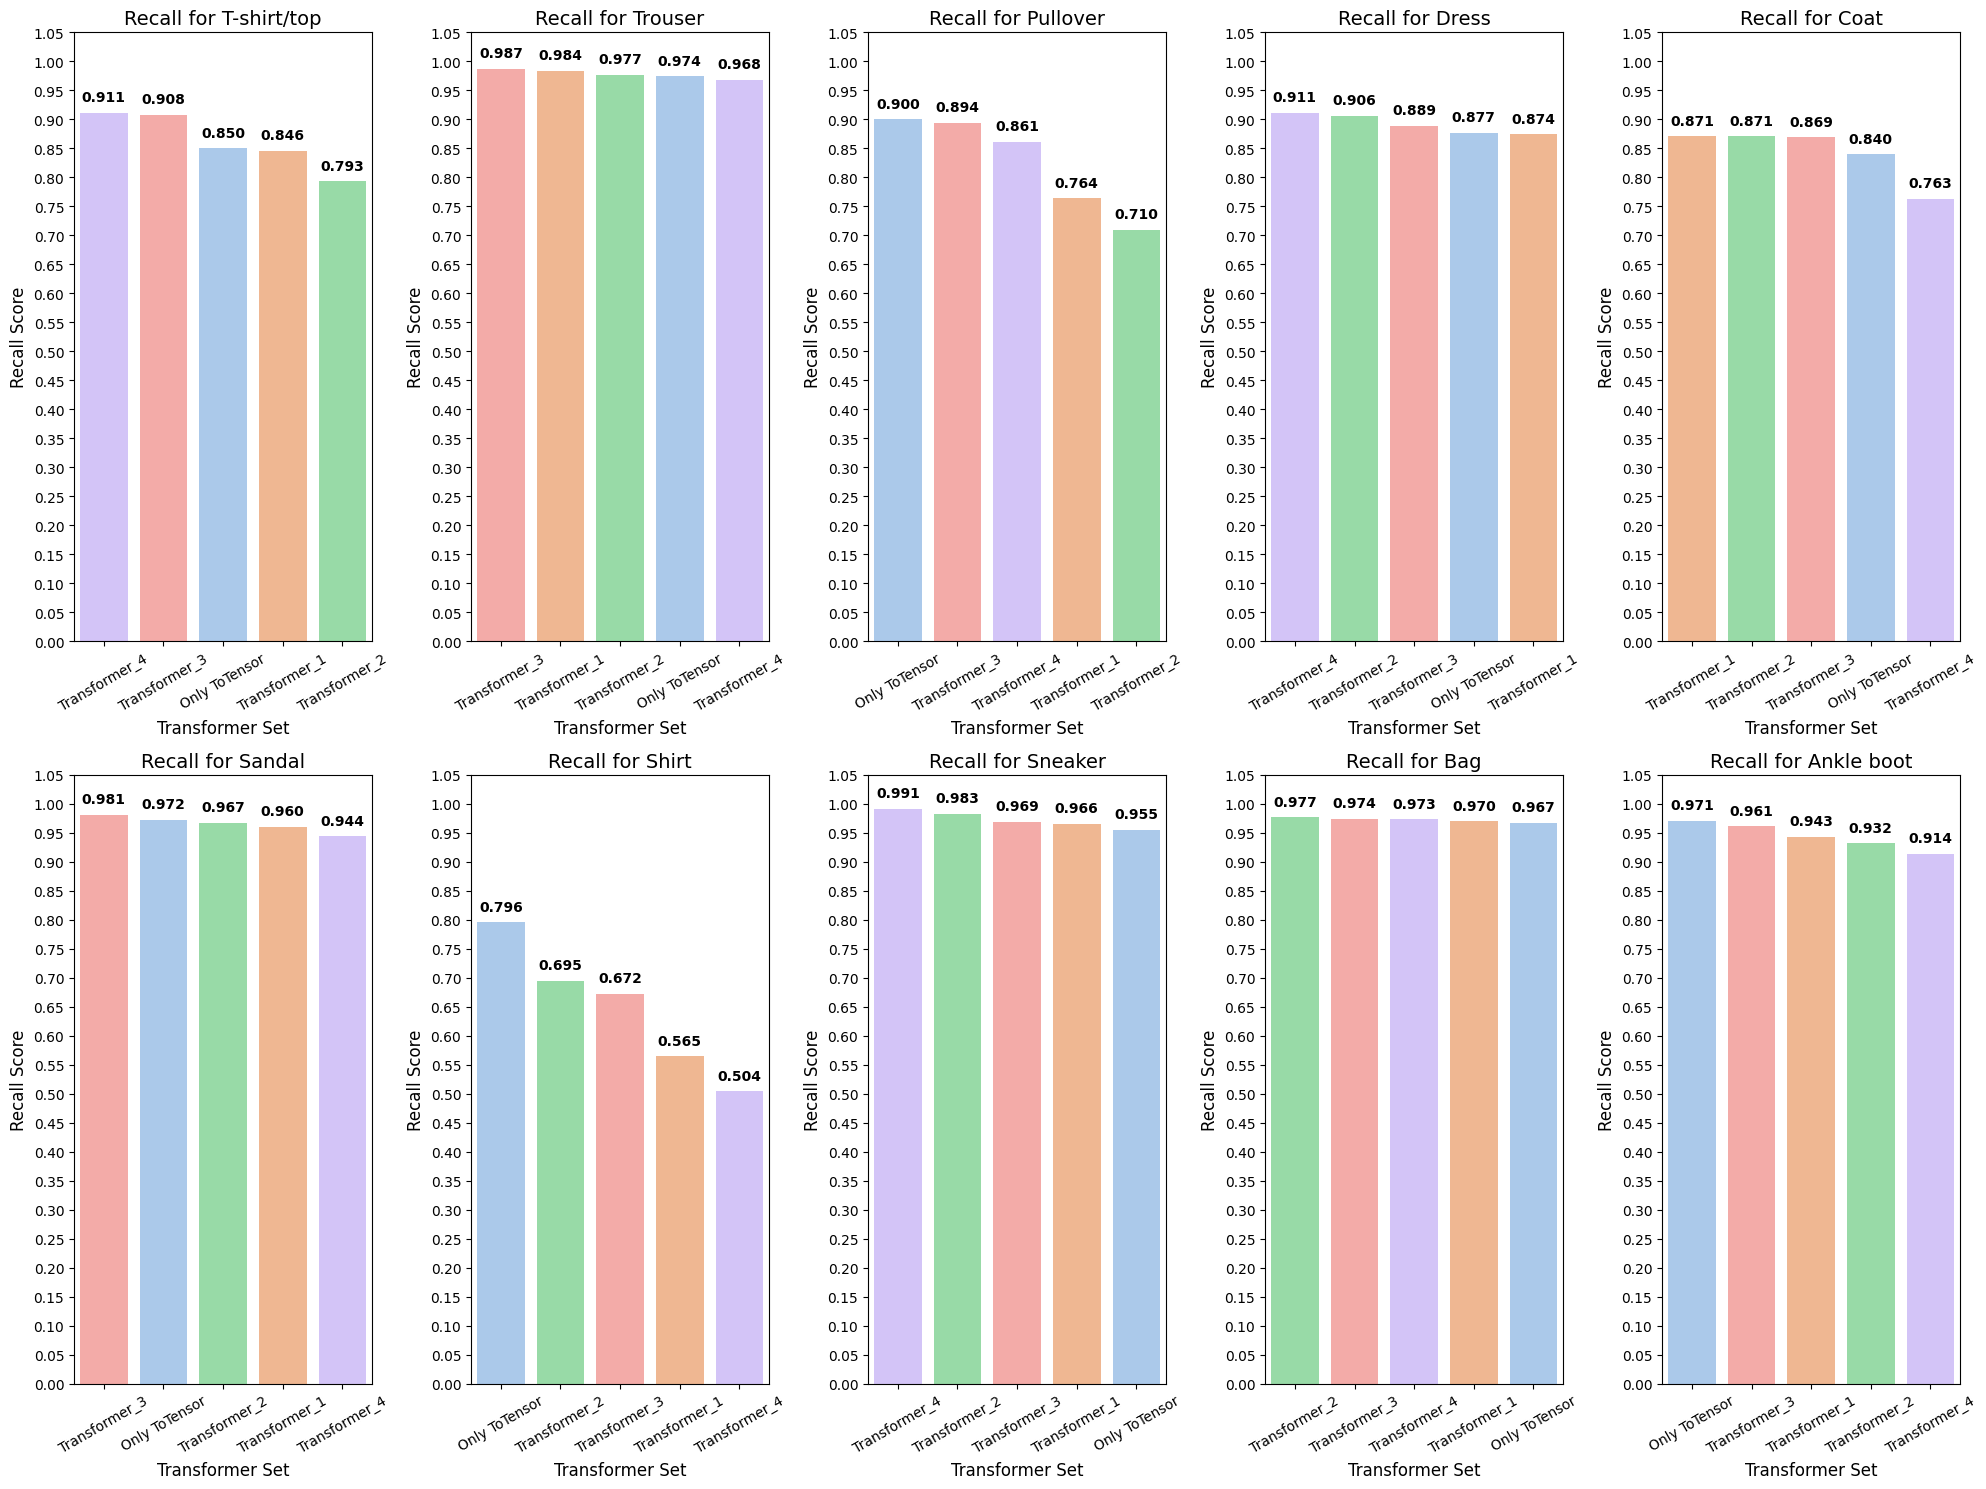

In [498]:
# Set the figure size dynamically based on the number of clothing categories
num_categories = len(df_recall.columns) - 1  # Exclude "Transformer Set"
num_rows = (num_categories // 3) + (num_categories % 3 > 0)  # Arrange in rows of 3
fig, axes = plt.subplots(2, 5, figsize=(20, 15))  # Grid layout

# Flatten axes array if it's a multi-row layout
axes = axes.flatten()

# Define a pastel color palette with specific colors assigned to each Transformer Set
transformer_sets = df_recall["Transformer Set"].unique()
pastel_colors = sns.color_palette("pastel", len(transformer_sets))
color_mapping = dict(zip(transformer_sets, pastel_colors))  # Assign each Transformer a color

# Plot each category
for i, category in enumerate(df_recall.columns[1:]):  # Skip "Transformer Set"
    # Sort dataframe by recall values (descending order)
    sorted_df = df_recall.sort_values(by=category, ascending=False)

    # Plot the bar chart with a specific color for each Transformer Set
    ax = axes[i]  # Reference to current subplot
    sns.barplot(data = sorted_df, 
                x = "Transformer Set", 
                y = category, 
                ax = ax, 
                palette = color_mapping,  # Use fixed colors per Transformer Set
                hue = "Transformer Set",
                dodge = False)  # Ensures bars are not split into groups

    # Customize subplot
    ax.set_title(f"Recall for {category}", fontsize=14)
    ax.set_xlabel("Transformer Set", fontsize=12)
    ax.set_ylabel("Recall Score", fontsize=12)
    ax.set_ylim(0, 1.05)  # Extend limit slightly for better label placement
    ax.tick_params(axis='x', rotation=30)  # Rotate x-axis labels for readability
    ax.set_yticks(np.arange(0, 1.1, 0.05))

    for p in ax.patches:  # Iterate through bars
        height = p.get_height()  # Get bar height (recall value)
        x_position = p.get_x() + p.get_width() / 2  # Get bar center position
        ax.text(x_position, height + 0.02, f"{height:.3f}", 
                ha='center', fontsize=10, fontweight='bold', color='black')

# Hide empty subplots if num_categories is not a multiple of 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove extra subplots

# Adjust layout
plt.tight_layout()
plt.show()


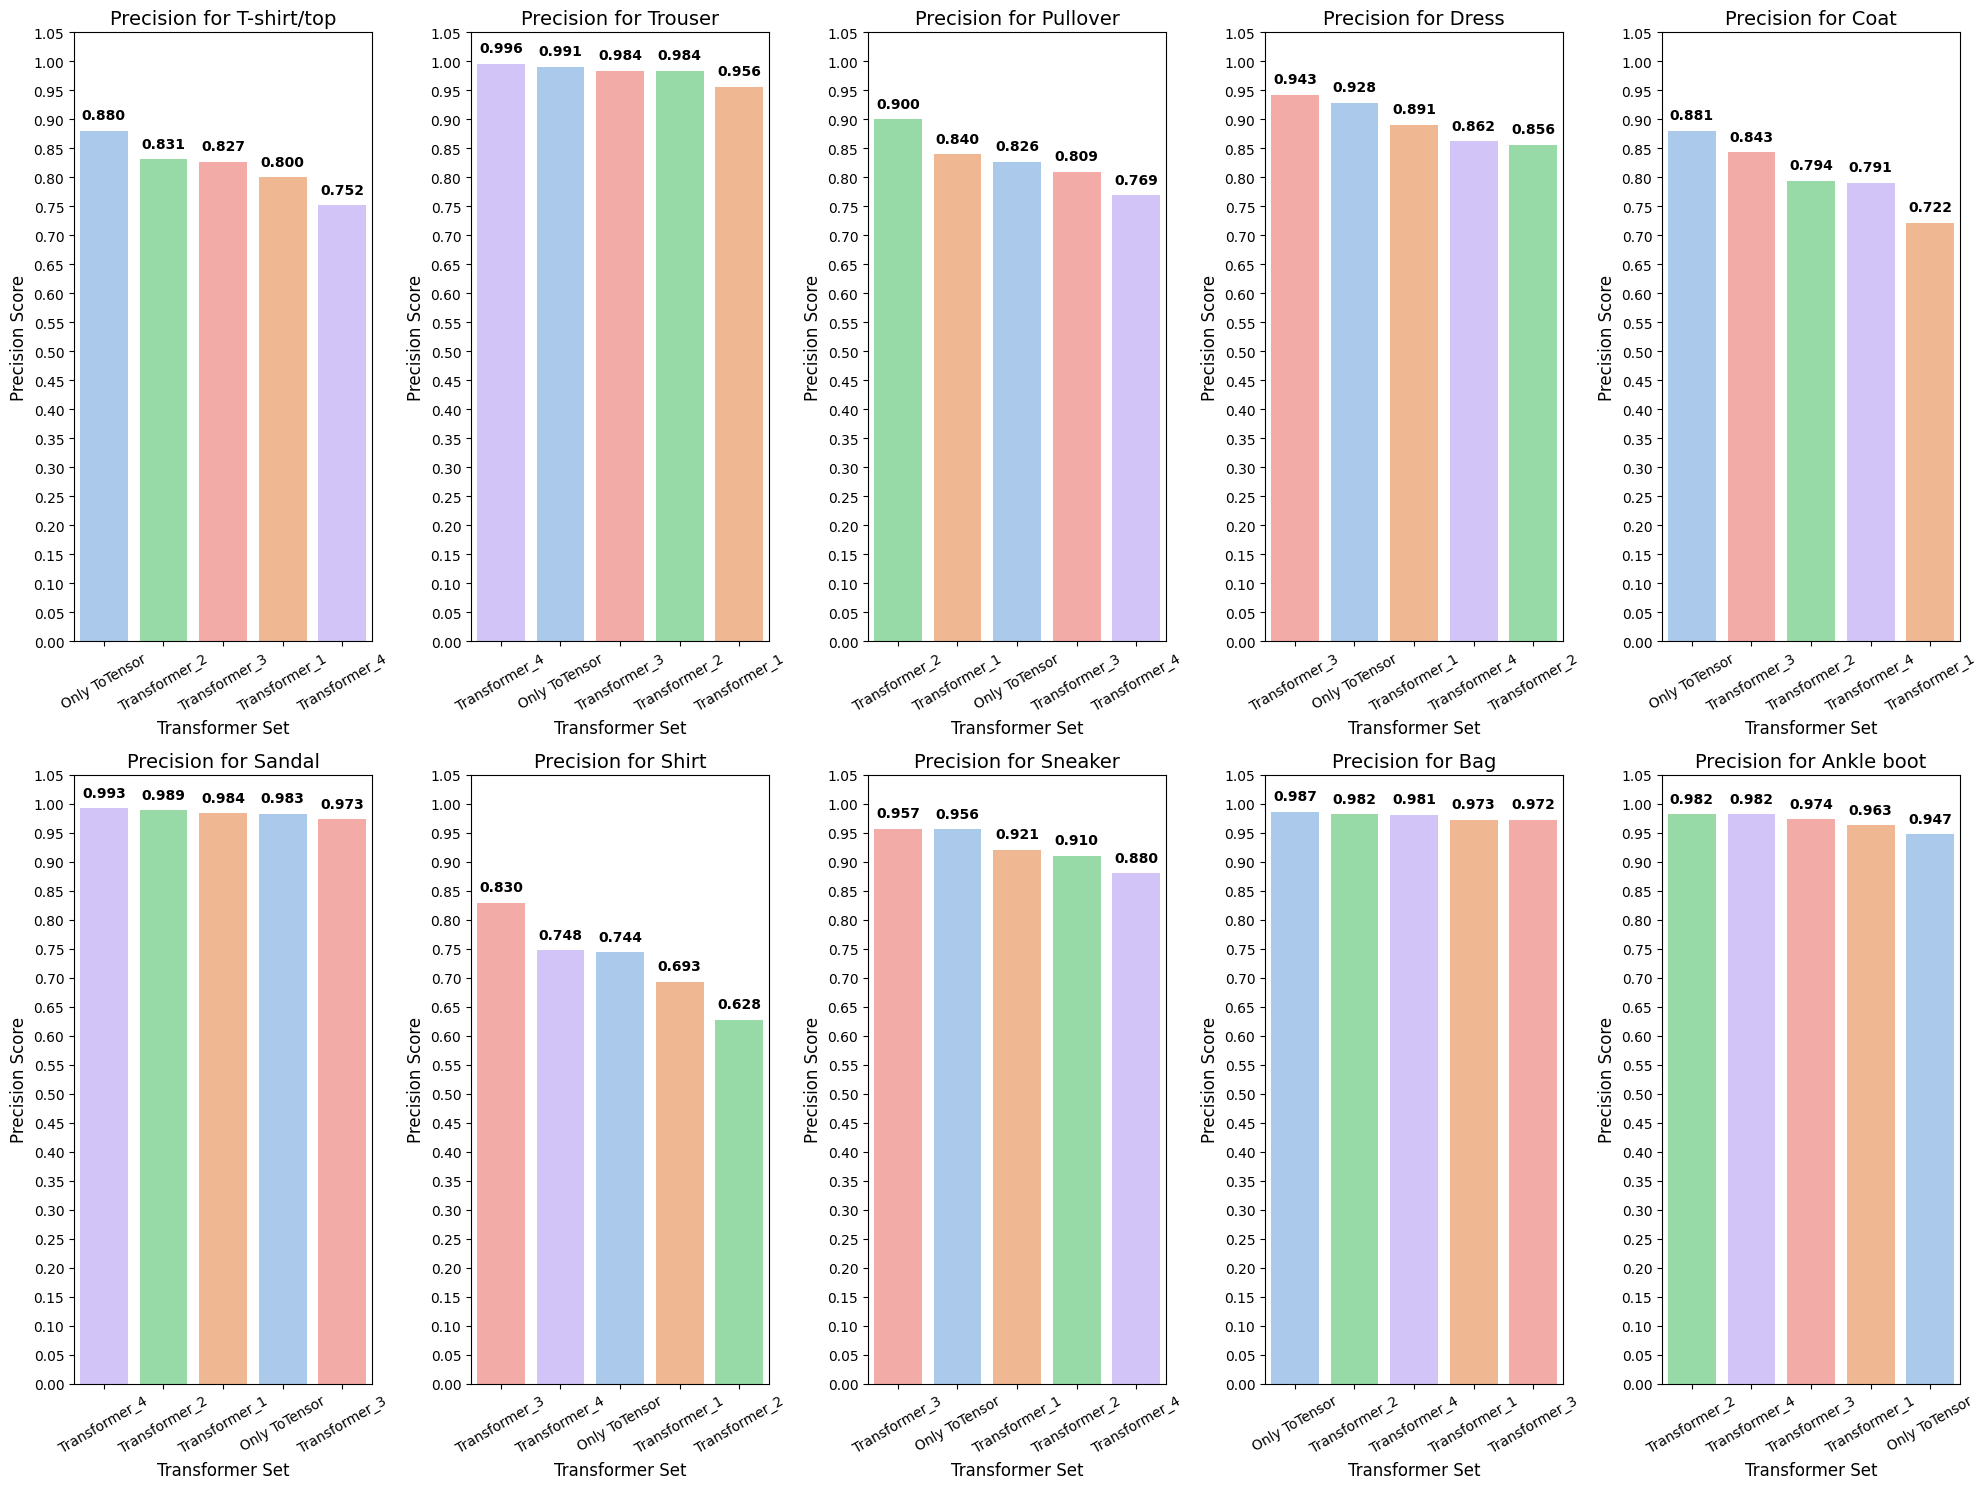

In [499]:
# Set the figure size dynamically based on the number of clothing categories
num_categories = len(df_precision.columns) - 1  # Exclude "Transformer Set"
num_rows = (num_categories // 3) + (num_categories % 3 > 0)  # Arrange in rows of 3
fig, axes = plt.subplots(2, 5, figsize=(20, 15))  # Grid layout

# Flatten axes array if it's a multi-row layout
axes = axes.flatten()

# Define a pastel color palette with specific colors assigned to each Transformer Set
transformer_sets = df_precision["Transformer Set"].unique()
pastel_colors = sns.color_palette("pastel", len(transformer_sets))
color_mapping = dict(zip(transformer_sets, pastel_colors))  # Assign each Transformer a color

# Plot each category
for i, category in enumerate(df_precision.columns[1:]):  # Skip "Transformer Set"

    # Sort dataframe by precision values (descending order)
    sorted_df = df_precision.sort_values(by=category, ascending=False)

    # Plot the bar chart with a specific color for each Transformer Set
    ax = axes[i]  # Reference to current subplot
    sns.barplot(data = sorted_df, 
                x = "Transformer Set", 
                y = category, 
                ax = ax, 
                palette = color_mapping,  # Use fixed colors per Transformer Set
                hue = "Transformer Set",
                dodge = False)  # Ensures bars are not split into groups

    # Customize subplot
    ax.set_title(f"Precision for {category}", fontsize=14)
    ax.set_xlabel("Transformer Set", fontsize=12)
    ax.set_ylabel("Precision Score", fontsize=12)
    ax.set_ylim(0, 1.05)  # Extend limit slightly for better label placement
    ax.tick_params(axis='x', rotation=30)  # Rotate x-axis labels for readability
    ax.set_yticks(np.arange(0, 1.1, 0.05))

    for p in ax.patches:  # Iterate through bars
        height = p.get_height()  # Get bar height (recall value)
        x_position = p.get_x() + p.get_width() / 2  # Get bar center position
        ax.text(x_position, height + 0.02, f"{height:.3f}", 
                ha='center', fontsize=10, fontweight='bold', color='black')

# Hide empty subplots if num_categories is not a multiple of 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove extra subplots

# Adjust layout
plt.tight_layout()
plt.show()


In [503]:
# Rank precision values in descending order for each category (higher is better)
df_precision_ranked = df_precision.copy()

# Apply ranking to all columns except "Transformer Set"
df_precision_ranked.iloc[:, 1:] = df_precision.iloc[:, 1:].rank(ascending=False, method='dense')

df_precision_ranked["Average Rank"] = df_precision_ranked.iloc[:, 1:].mean(axis=1)

df_precision_ranked = df_precision_ranked.sort_values(by="Average Rank")

df_precision_ranked

,Transformer Set,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot,Average Rank
0,Only ToTensor,1.0,2.0,3.0,2.0,1.0,4.0,3.0,2.0,1.0,5.0,2.4
3,Transformer_3,3.0,3.0,4.0,1.0,2.0,5.0,1.0,1.0,5.0,3.0,2.8
2,Transformer_2,2.0,4.0,1.0,5.0,3.0,2.0,5.0,4.0,2.0,1.0,2.9
4,Transformer_4,5.0,1.0,5.0,4.0,4.0,1.0,2.0,5.0,3.0,2.0,3.2
1,Transformer_1,4.0,5.0,2.0,3.0,5.0,3.0,4.0,3.0,4.0,4.0,3.7
